# P1 실습: 머신러닝 프로젝트와 회귀 모델 훈련

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 강의노트이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

## 공통 환경설정

### 환경설정

This project requires Python 3.10 or above:

In [1]:
import sys

assert sys.version_info >= (3, 10)

It also requires Scikit-Learn ≥ 1.6.1:

In [2]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

Let's define the default font sizes, to plot pretty figures:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

**기본 라이브러리**

In [4]:
import numpy as np
import pandas as pd

# 실습 1. End-to-end 회귀 프로젝트

캘리포니아 주택가격 데이터를 이용해
**데이터 구하기 → 탐색 → train/test → 훈련셋 EDA → 입력/타깃 → 전처리 → Pipeline → 선형 회귀**
흐름을 따라간다.

#### 데이터 구하기

캘리포니아 주택 가격 데이터는 매우 유명하여 많은 공개 저장소에서 다운로드할 수 있다.
여기서는 개인 깃허브 리포지토리에 압축파일로 저장한 파일을 다운로드해서 사용한다.

아래 코드의 `load_housing_data()` 함수는
지정된 깃허브 리포지토리에 tgz 형식의 압축 파일로 저장되어 있는
캘리포니아 주택 가격 데이터를 다운로드한 후에 
Pandas 데이터프레임으로 변환하여 반환한다.
최종적으로 `housing_full` 변수는 캘리포니아 주택 가격 데이터를 담고 있는 데이터프레임을 가리킨다.

**데이터셋 다운로드**

In [5]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

### 데이터셋 탐색

데이터 탐색은 훈련을 시작하기 전에 주어진 데이터셋의
다양한 특성을 대략적으로 살펴보는 과정이다.
데이터 시각화는 데이터 탐색을 위한 주요 기법 중의 하나이다.
먼저 데이터프레임의 메서드를 활용한 데이터 탐색을 알아본다.

#### 데이터프레임 활용

In [6]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [8]:
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


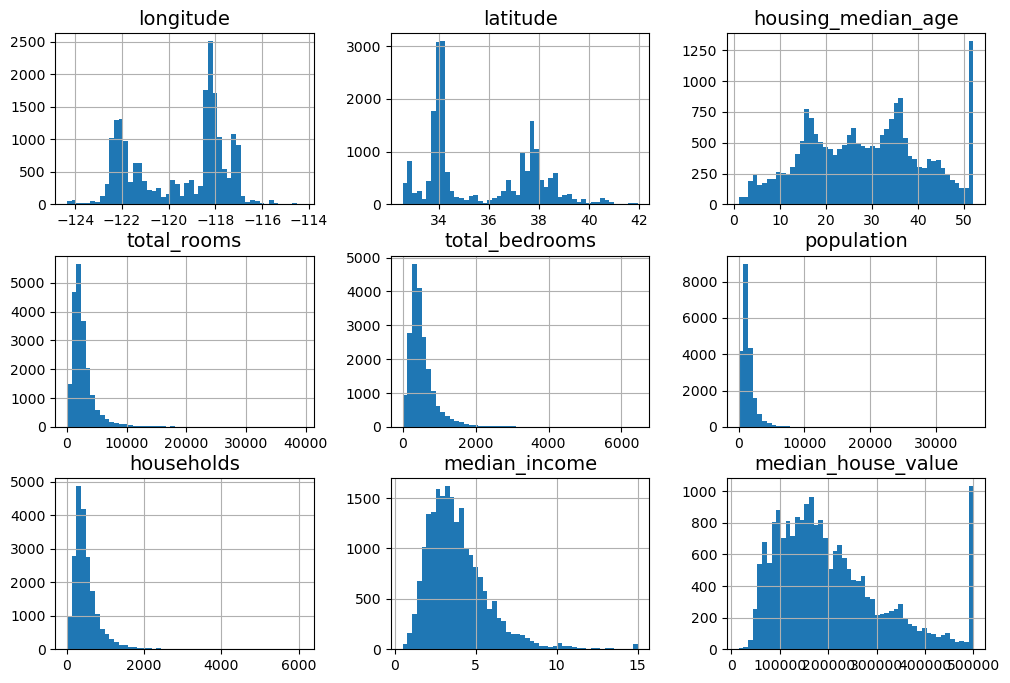

In [10]:
housing_full.hist(bins=50, figsize=(12, 8))

plt.show()

### 훈련셋과 테스트셋

모델 훈련을 시작하기 전에 전체 데이터셋을 보통 **훈련셋**<font size='2'>training set</font>과
**테스트셋**<font size='2'>test set</font>으로 나눈다.

테스트셋은 훈련 과정에서 전혀 사용하지 않는 데이터이며, 보통 전체 데이터셋의 약 10~20% 정도를 차지하도록 정한다.
다만 전체 데이터셋의 크기에 따라 테스트셋의 비율은 적절히 조절할 수 있다.

- **훈련셋**: 머신러닝 모델을 훈련하는 데 사용하는 데이터셋이다.
  실제 모델 훈련을 시작하기 전에 입력 데이터셋과 타깃 데이터셋으로 다시 나눈다.

- **테스트셋**: 훈련을 마친 모델의 성능을 평가하기 위해 사용하는 데이터셋이다.
  훈련 과정에서는 어떤 방식으로도 사용하지 않는다.
  모델 평가를 진행하기 전에 훈련셋과 동일한 기준에 따라 입력 데이터셋과 타깃 데이터셋으로 나눈다.

#### 무작위 샘플링

전체 데이터에서 무작위로 샘플을 추출하는 방식이다.
데이터셋이 매우 크다면 모집단을 잘 대표할 수 있지만, 그렇지 않을 경우 샘플링 편향이 발생해 특정 특징을 가진 데이터가 과하게 많거나 적게 추출될 위험이 있다.

In [11]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

<Axes: >

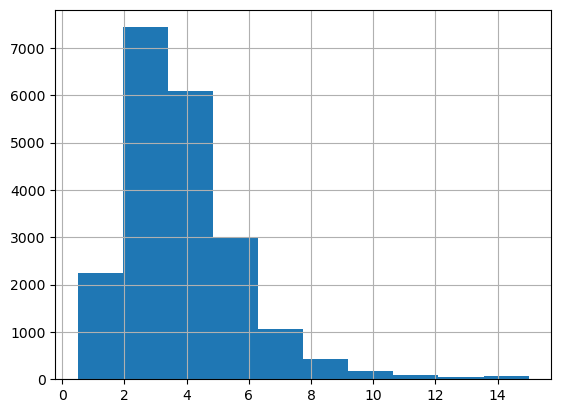

In [12]:
housing_full['median_income'].hist()

In [13]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])

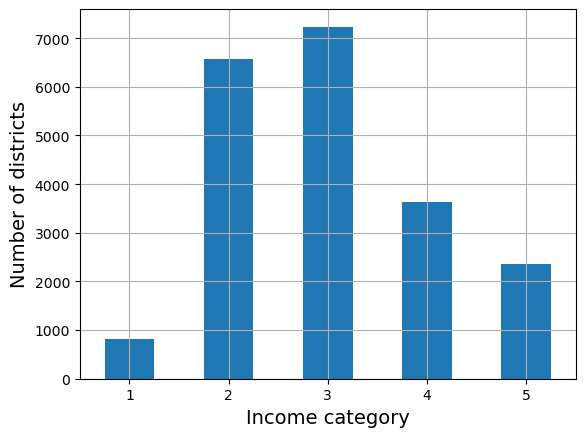

In [14]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()

In [15]:
strat_train_set, strat_test_set = train_test_split(
    housing_full, 
    test_size=0.2,
    stratify=housing_full["income_cat"],            # 계층 샘플링을 위한 기준이 되는 열 지정
    random_state=42)

In [16]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

### 훈련셋 살펴보기

데이터 살펴보기는 훈련셋만을 대상으로 진행한다.
이유는 머신러닝 모델에 사용될 좋은 훈련셋으로 활용하는 방안을 모색하기 위해서인데,
테스트셋을 사용하면 미래에 발생할 데이터를 안다고 가정하는 결과를 초래하기 때문이다.

훈련셋은 캘리포니아 전체 데이터셋에서 앞서 계층 샘플링을 이용하여 얻어진 데이터셋으로 지정한다.
아래 코드는 `housing` 변수가 가리키는 데이터셋 객체를 전체 데이터셋에서
계층 샘플링을 이용하여 생성된 훈련셋의 복사본으로 지정한다.

In [17]:
housing = strat_train_set.copy()

#### 피어슨 상관관계

앞으로 훈련시킬 모델은 어떤 구역의 중위 주택가격을 제외한 다른 특성이 주어졌을 때
해당 구역의 중위 주택가격을 예측해야 한다.
따라서 중위 주택가격과 상관관계가 높은 특성을 미리 확인해볼 필요가 있다.

특성들 사이의 선형 상관관계를 피어슨 상관계수로 계산한다.
단, 수치형 특성만 대상으로 한다.

In [18]:
corr_matrix = housing.corr(numeric_only=True)

### 타깃 대 입력 데이터셋

지도학습 방식으로 중위 주택가격을 예측하는 모델을 훈련시키려면
훈련셋을 타깃셋과 입력 데이터셋으로 분리해야 한다.
입력 데이터셋 또한 일반적으로 훈련셋으로 불린다.

In [19]:
# 훈련셋 (입력 데이터셋)
housing = strat_train_set.drop("median_house_value", axis=1)

# 타깃셋
housing_labels = strat_train_set["median_house_value"].copy()

### 데이터 정제와 전처리

데이터 탐색을 통해 확인한 지도학습 회귀 모델을 훈련시키기 위해 먼저
적절한 훈련셋(입력 데이터셋)을 준비해야 한다.
적절한 훈련셋(입력 데이터셋) 준비는 데이터 정제와 데이터 전처리 과정으로 이루어진다.

#### 데이터 전처리

데이터 전처리<font size='2'>Data Preprocessing</font>는
모델 훈련에 적합한 훈련셋(입력 데이터셋)을 만들어가는 과정을 가리킨다.
예를 들어, 캘리포니아 주택 가격 데이터셋에 포함된 수치형 특성과 범주형 특성에 대해
각각 아래 전처리 과정을 거친다.

* 범주형 특성 전처리: 원-핫-인코딩
* 수치형 특성 전처리: 특성 스케일링과 특성 조합

### 사이킷런 API 활용

데이터 정제와 전처리 전과정을 사이킷런 라이브러리에서 제공하는 API를 활용한다.
먼저 사이킷런 API의 기본 특성을 살펴본 다음에 앞서 언급된 정제와 전처리 내용을 
처리하는 각각의 API를 하나씩 살펴본다.
그런 다음 사이킷런 API를 연동하여 정제와 전처리 전 과정을 
한꺼번에 순차적으로 처리하는 파이프라인<font size='2'>pipeline</font>으로 구성하여
자동화는 방식까지 소개한다.

#### 결측치 처리

`'total_bedrooms'` 특성에 결측치(`NaN`)가 일부 포함되어 있다.

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [21]:
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [22]:
X = imputer.fit_transform(housing_num)

#### 원-핫 인코딩

해안 근접도(`ocean_proximity`)는 문자열을 사용한다.

In [23]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [24]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [25]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

In [26]:
pd.DataFrame(housing_cat_1hot,
             columns=cat_encoder.get_feature_names_out(),
             index=housing_cat.index)

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0
14689,0.0,1.0,0.0,0.0,0.0
20507,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
14207,1.0,0.0,0.0,0.0,0.0
13105,0.0,1.0,0.0,0.0,0.0
19301,0.0,0.0,0.0,0.0,1.0
19121,1.0,0.0,0.0,0.0,0.0


#### 특성 스케일링

**min-max 스케일링**

min-max 스케일링은 정규화의 한 방식이다.
아래 식을 이용하여 특성값 $x$를 0에서 1 사이의 값으로 변환한다.
$max$ 와 $min$ 은 각각 해당 특성값들의 최댓값과 최솟값을 가리킨다.

$$
\frac{x-min}{max-min}
$$

min-max 스케일링은 이상치에 매우 민감하다.
예를 들어 이상치가 매우 크면 분모가 분자에 비해 훨씬 크게 되어 변환된 값이 0 근처에 몰리게 된다.
사이킷런의 `MinMaxScaler` 변환기가 min-max 스케일링을 지원한다.

In [27]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

In [28]:
housing_num_std_scaled

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.13746004,
         1.39481249, -0.93649149],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.69377062,
        -0.37348471,  1.17194198],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.78876841,
        -0.77572662, -0.75978881],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  1.26829911,
         0.67913534,  0.1010487 ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.27356264,
         0.88286825,  0.14539615],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.67915557,
        -0.75221898, -0.31034135]], shape=(16512, 8))

### 파이프라인

데이터 정제와 전처리의 모든 단계가 정확한 순서대로 진행되어야 한다.
사이킷런은 여러 변환기를 순차적으로 또는 병렬적으로 실행하는
파이프라인 기능을 지원한다.

사이킷런에서 제공하는 파이프라인 관련 주요 API는 다음과 같다.

| API | 설명 |
|---|---|
| `Pipeline` 클래스 | 이름으로 구분된 여러 추정기(변환기, 예측기)를 순차적으로 연결하여 파이프라인 구성. 단 예측기가 사용되는 경우 맨 마지막에 추가 |
| `make_pipeline()` 함수 | 추정기 이름 지정 없이 간편하게 `Pipeline` 객체 생성 |
| `ColumnTransformer` 클래스 | 특성마다 다른 변환기를 병렬 적용 후 결과 병합 |
| `make_column_transformer()` 함수 | 이름 지정 없이 간편하게 `ColumnTransformer` 객체 생성 |

In [29]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

#### `ColumnTransformer` 클래스

특성별로 파이프라인을 지정할 수 있다.

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# 수치형 특성 리스트 지정
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
# 범주형 특성 리스트 지정
cat_attribs = ["ocean_proximity"]

# 범주형 특성 변환 파이프라인
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

# 전체 특성 변환기
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

### 모델 선택과 훈련

`preprocessing`에 의해 변환되는 데이터프레임은 예측기 모델의 훈련에
바로 사용될 수 있다.
즉, 이제 머신러닝 예측기 모델의 훈련셋으로 바로 사용할 수 있다.

하지만 여기서는 데이터 변환과 모델 훈련을 분리해서 진행하는 대신
변환기와 예측기를 하나의 파이프라인으로 묶어
데이터 변환과 모델 훈련을 동시에 진행하는 방법을 선택해서 소개한다.

`preprocessing`이 가리키는 변환기와 함께 묶여 하나의 파이프라인으로 구성될 예측기로
사이킷런의 회귀 모델 세 개를 활용한다.
각 모델의 자세한 특징과 상세 설명은 이어지는 장에서 하나씩 소개할 예정이며,
여기서는 모델 선택에 따른 성능과 보다 좋은 모델을 훈련시키는 방법을 자세히 소개한다.

#### 모델 훈련과 평가

**선형회귀 모델 활용**

In [33]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [34]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)  # -2 = rounded to the nearest hundred

array([270900., 334800., 119900., 109200., 305600.])

In [35]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68232.83515124217

### 실습 1 확인

- 테스트셋을 먼저 분리하는 이유는 무엇인가?
- EDA를 훈련셋에서만 수행하는 이유는 무엇인가?
- `Pipeline`과 `ColumnTransformer`는 왜 필요한가?
- 훈련 RMSE만으로 일반화 성능을 판단할 수 있는가?

# 실습 2. 선형 회귀 배치 경사하강법

`code-training_models.ipynb`의 **선형 회귀 배치 학습 실험**을 이용해
MSE, 경사하강법, 학습률의 역할을 확인한다.

### 선형 회귀 배치 학습 실험

**실험용 학습 데이터 생성 및 시각화**

배치 경사하강법 실험을 위한 훈련 데이터를 생성한다.
실제 관계는 

$$y = 4 + 3\, x_1 + \text{noise}$$

이며, 0에서 2 사이의 구간에서 200개의 샘플을 균등하게 무작위로 선택한다.
즉, $x_1 \sim U(0, 2)$이 성립한다.
$y$ 값에 추가된 노이즈 또한 0에서 1 사이의 구간에서 균등하게 무작위로 선택된다.

아래 코드는 데이터 생성과 생성된 데이터를 산점도를 그린다.

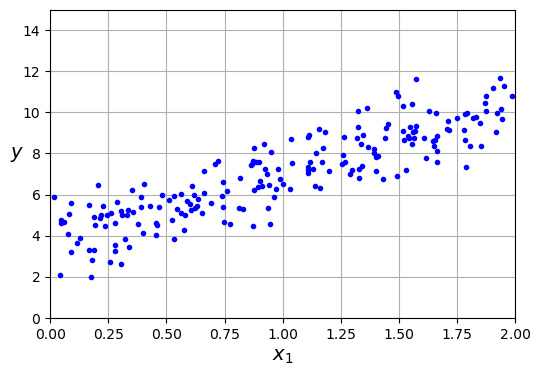

In [36]:
rng = np.random.default_rng(seed=42)  # 재현 가능한 난수 생성기 (시드 고정)
m = 200  # 훈련 샘플 수

# 입력 특성: [0, 2) 구간에서 균등 분포로 200개 샘플 생성 → (200, 1) 형태
X = 2 * rng.random((m, 1))

# 타깃값: y = 4 + 3*x1 + 가우시안 잡음 (평균 0, 표준편차 1)
y = 4 + 3 * X + rng.standard_normal((m, 1))

# 산점도 시각화
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")         # 파란 점으로 데이터 표시
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])     # x축 구간: [0, 2], y축 구간: [0, 15]
plt.grid()

plt.show()

**배치 경사하강법 시각화 함수 정의**

`plot_gradient_descent(theta, eta)` 함수를 정의한다. 
이 함수는 초기 파라미터 `theta`와 학습률 `eta`를 입력받아 1000 에포크 동안 배치 경사하강법을 실행한다. 
처음 20 에포크 동안 매 에포크마다 훈련된 선형 회귀 모델의 예측값을 직선으로 그려 
학습된 편향과 절편의 변화를 시각적으로 보여준다.

각 에포크에서의 비용 함수의 그래디언트는 아래 수식으로 계산되며, 
아래 코드에서 `gradients` 변수가 이를 가리킨다.

$$\nabla_\theta \text{MSE} = \frac{2}{m} X^T (X\theta - y)$$

In [37]:
import matplotlib as mpl
from sklearn.preprocessing import add_dummy_feature

# 훈련 데이터에 편향 항(x0 = 1) 추가 → (200, 2) 형태: [1, x1]
X_b = add_dummy_feature(X)

# 예측선 시각화를 위한 새로운 입력값: x1 = 0과 x1 = 2 두 점
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # 편향 항 추가 → [[1, 0], [1, 2]]

def plot_gradient_descent(theta, eta):
    """
    배치 경사하강법을 실행하고 수렴 과정을 시각화한다.
    - theta: 초기 파라미터 (편향 θ0, 기울기 θ1)
    - eta: 학습률
    """
    m = len(X_b)           # 훈련 샘플 수
    plt.plot(X, y, "b.")   # 훈련 데이터 산점도
    n_epochs = 1000        # 총 에포크 수
    n_shown = 20           # 처음 n_shown 에포크의 예측선만 시각화
    theta_path = []        # 에포크별 파라미터 저장 리스트

    for epoch in range(n_epochs):
        if epoch < n_shown:
            # 현재 theta로 예측선 계산 후 시각화 (에포크 순서에 따라 색상 변화)
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)

        # 배치 경사하강법: 전체 훈련 데이터로 그래디언트 계산
        # ∇MSE = (2/m) * X_b^T @ (X_b @ theta - y)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)

        # 파라미터 업데이트: θ ← θ - η * ∇MSE
        theta = theta - eta * gradients
        theta_path.append(theta)   # 업데이트된 파라미터 저장

    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")  # 서브플롯 제목에 학습률 표시
    return theta_path

**학습률에 따른 배치 경사하강법 수렴 비교**

세 가지 학습률($\eta$)로 배치 경사하강법을 실행하여 결과를 비교한다.

- $\eta = 0.02$ (너무 작음): 스텝 크기가 작아 수렴이 매우 느리고, 1000 에포크 안에 최적해에 도달하지 못할 수 있다.
- $\eta = 0.1$ (적절함): 빠르고 안정적으로 최적해에 수렴한다.
- $\eta = 0.5$ (너무 큼): 스텝이 지나치게 커서 최솟값을 건너뛰며 발산하거나 진동한다.

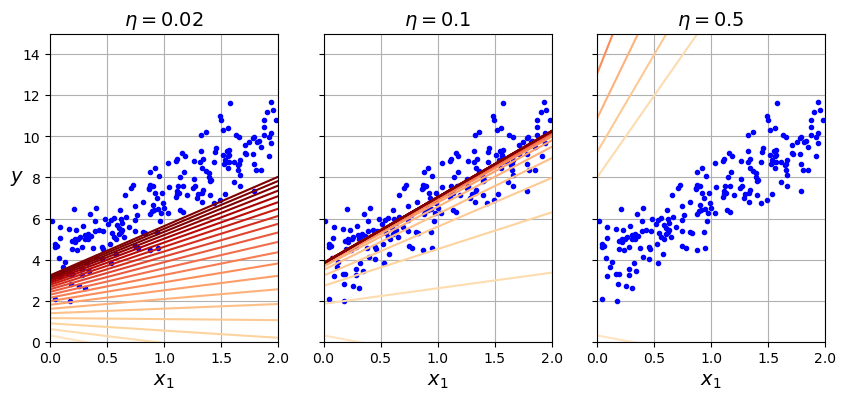

In [38]:
rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # 파라미터 무작위 초기화: [θ0(편향), θ1(기울기)]

plt.figure(figsize=(10, 4))

# 왼쪽 서브플롯: η = 0.02 (학습률 너무 작음 → 느린 수렴)
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)

# 가운데 서브플롯: η = 0.1 (적절한 학습률 → 빠르고 안정적인 수렴)
# theta_path_bgd에 에포크별 파라미터를 저장 (이후 확률적/미니배치 경사하강법 비교에 활용)
plt.subplot(132)
plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])  # y축 눈금 레이블 숨김

# 오른쪽 서브플롯: η = 0.5 (학습률 너무 큼 → 발산 또는 진동)
plt.subplot(133)
plot_gradient_descent(theta, eta=0.5)
plt.gca().axes.yaxis.set_ticklabels([])  # y축 눈금 레이블 숨김

plt.show()

### 실습 2 확인

- 매 에포크마다 어떤 값이 갱신되는가?
- 학습률이 너무 작거나 크면 어떻게 되는가?
- 학습률은 파라미터인가 하이퍼파라미터인가?

# 실습 3. 교차 검증, 규제, 최종 테스트

다시 캘리포니아 주택가격 문제로 돌아가
기존 `code-end2end_ml_project.ipynb`의 교차 검증과 테스트셋 활용 방식을 적용한다.
P1 이론 범위에 맞춰 선형 회귀와 Ridge 회귀를 비교한다.

#### 교차 검증

**사이킷런의 `cross_val_score()` 함수**

`cross_val_score()` 함수는 지정된 모델을 k-겹 교차 검증을 활용하여 훈련과 평가를 동시에 진행한다.
교차검증은 다만 모델 평가용도로만 폴드를 구분하여 훈련할 뿐 훈련된 모델 객체 자체를 반환하지는 않는다.
예를 들어 아래 코드는 결정트리 모델에 대해 교차 검증을 실행한다.

결정트리 모델의 교차검증 보다 약간 나쁘게 나온다.

In [41]:
from sklearn.model_selection import cross_val_score

lin_rmses = -cross_val_score(lin_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=5)
pd.Series(lin_rmses).describe()

count        5.000000
mean     68321.573834
std        395.293609
min      67951.482921
25%      68000.954696
50%      68175.309287
75%      68657.575745
max      68822.546519
dtype: float64

### Ridge 회귀 비교

`training_models.ipynb`에서 다룬 Ridge 규제를
앞에서 정의한 동일한 전처리 파이프라인과 결합한다.

In [42]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import pandas as pd

ridge_results = {}

for alpha in [0.1, 1.0, 10.0, 100.0]:
    ridge_reg = make_pipeline(preprocessing, Ridge(alpha=alpha))
    rmses = -cross_val_score(
        ridge_reg,
        housing,
        housing_labels,
        scoring="neg_root_mean_squared_error",
        cv=5
    )
    ridge_results[f"Ridge(alpha={alpha})"] = {
        "mean_RMSE": rmses.mean(),
        "std_RMSE": rmses.std()
    }

ridge_results["LinearRegression"] = {
    "mean_RMSE": lin_rmses.mean(),
    "std_RMSE": lin_rmses.std()
}

cv_summary = pd.DataFrame(ridge_results).T.sort_values("mean_RMSE")
cv_summary

,mean_RMSE,std_RMSE
LinearRegression,68321.573834,353.561352
Ridge(alpha=0.1),68321.788304,352.401793
Ridge(alpha=1.0),68331.785994,347.686915
Ridge(alpha=10.0),68363.083779,346.810231
Ridge(alpha=100.0),68416.934277,363.742956


교차 검증 평균 RMSE가 가장 작은 후보를 선택한다.
테스트셋은 이 선택 과정에 사용하지 않는다.

In [43]:
best_name = cv_summary.index[0]

if best_name == "LinearRegression":
    final_model = lin_reg
else:
    best_alpha = float(best_name.split("=")[1].rstrip(")"))
    final_model = make_pipeline(preprocessing, Ridge(alpha=best_alpha))

final_model.fit(housing, housing_labels)
best_name

'LinearRegression'

### 테스트셋 활용

선택이 끝난 뒤 기존 end-to-end 실습의 최종 테스트 절차와 같은 방식으로
일반화 성능을 확인한다.

In [44]:
from sklearn.metrics import root_mean_squared_error

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)

print("선택 모델:", best_name)
print("테스트 RMSE:", final_rmse)

선택 모델: LinearRegression
테스트 RMSE: 71002.83776920449


## P1 실습 정리

> **데이터 구하기 → 탐색 → train/test → 훈련셋 EDA → 입력/타깃 → 전처리 → Pipeline → 선형 회귀 → 경사하강법 → 교차 검증 → Ridge 비교 → 최종 테스트**

이후 별도의 P1 프로젝트에서 같은 사고 흐름을 Bike Sharing 데이터에 적용한다.